ANALISIS EXPLORATORIO DE LOS DATOS


In [3]:
%pip install PyYAML

import csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import yaml


  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl (156 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#poblacionNINI_df = config["sources"]["poblacion_nini"]["path"]
#print(poblacionNINI_df)


NameError: name 'config' is not defined

In [7]:
poblacionNINI_df = ("C://Users//57313//Desktop//Gestion y Almacenamiento de Datos//Proyecto_Final_Pobreza_Multidimensional//data//bronze//población_nini_entre_18_Y_28_anios_2025.csv")

In [10]:
%pip install fsspec

  Using cached fsspec-2026.9.0-py3-none-any.whl.metadata (10 kB)
Using cached fsspec-2026.9.0-py3-none-any.whl (221 kB)
Note: you may need to restart the kernel to use updated packages.


In [11]:
import fsspec
print(fsspec.__version__)

2026.9.0


In [12]:
with open(poblacionNINI_df, encoding="utf-8") as archivo:

    lineas = archivo.read().splitlines()

filas = []

for linea in lineas:

    if linea.startswith('"') and linea.endswith('"'):
        linea = linea[1:-1]

    linea = linea.replace('""', '"')

    fila = next(csv.reader([linea]))

    filas.append(fila)

columnas = filas[0]

df_NINI = pd.DataFrame(
    filas[1:],
    columns=columnas
)

df_NINI.head()

,Indicador,Periocidad,Desagregación geográfica,Dominio geográfico,año,Valor
0,porcentaje de población nini entre 18 y 28 años,anual,Departamental,Antioquia,2019,22.9
1,porcentaje de población nini entre 18 y 28 años,anual,Departamental,Antioquia,2018,24.7
2,porcentaje de población nini entre 18 y 28 años,anual,Departamental,Antioquia,2017,23.4
3,porcentaje de población nini entre 18 y 28 años,anual,Departamental,Antioquia,2016,22.3
4,porcentaje de población nini entre 18 y 28 años,anual,Departamental,Antioquia,2015,22.3


In [13]:
print("Filas:", df_NINI.shape[0])
print("Columnas:", df_NINI.shape[1])

print("\nColumnas:")
print(df_NINI.columns.tolist())

Filas: 300
Columnas: 6

Columnas:
['Indicador', 'Periocidad', 'Desagregación geográfica', 'Dominio geográfico', 'año', 'Valor']


In [14]:
df_NINI["año"] = pd.to_numeric(
    df_NINI["año"],
    errors="coerce"
)

df_NINI["Valor"] = pd.to_numeric(
    df_NINI["Valor"],
    errors="coerce"
)

In [15]:
df_NINI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Indicador                 300 non-null    object 
 1   Periocidad                300 non-null    object 
 2   Desagregación geográfica  300 non-null    object 
 3   Dominio geográfico        300 non-null    object 
 4   año                       300 non-null    int64  
 5   Valor                     300 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 14.2+ KB


In [16]:
df_NINI.describe()

,año,Valor
count,300.00000,300.000000
mean,2013.50000,28.115333
std,3.45782,5.545015
min,2008.00000,14.300000
25%,2010.75000,24.475000
50%,2013.50000,28.300000
75%,2016.25000,32.025000
max,2019.00000,43.100000


In [17]:
df_NINI.isnull().sum()

Indicador                   0
Periocidad                  0
Desagregación geográfica    0
Dominio geográfico          0
año                         0
Valor                       0
dtype: int64

In [18]:
df_NINI.duplicated().sum()

np.int64(0)

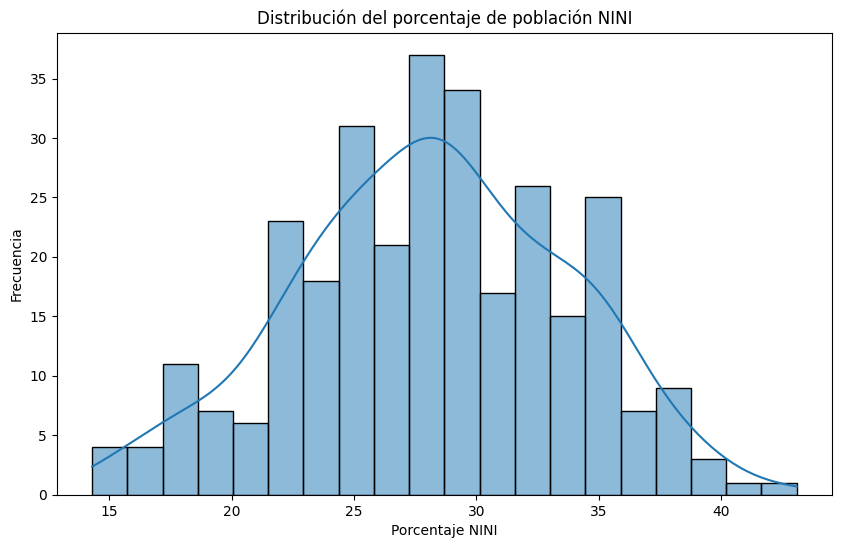

In [19]:

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_NINI,
    x="Valor",
    bins=20,
    kde=True
)

plt.title("Distribución del porcentaje de población NINI")
plt.xlabel("Porcentaje NINI")
plt.ylabel("Frecuencia")

plt.show()

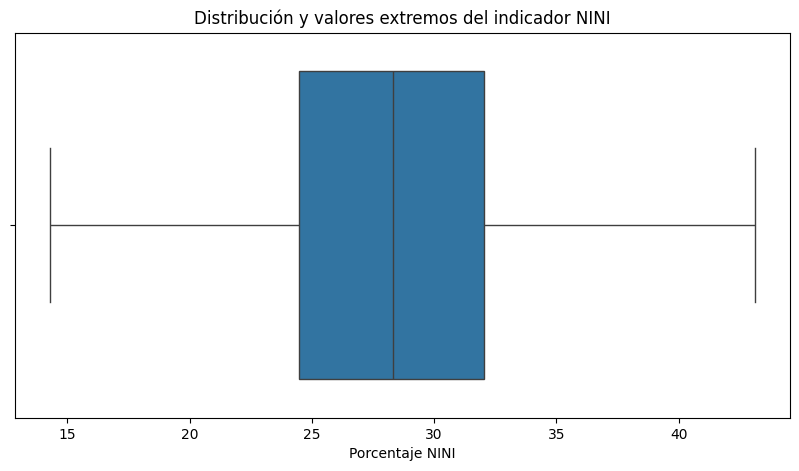

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_NINI,
    x="Valor"
)

plt.title("Distribución y valores extremos del indicador NINI")
plt.xlabel("Porcentaje NINI")

plt.show()

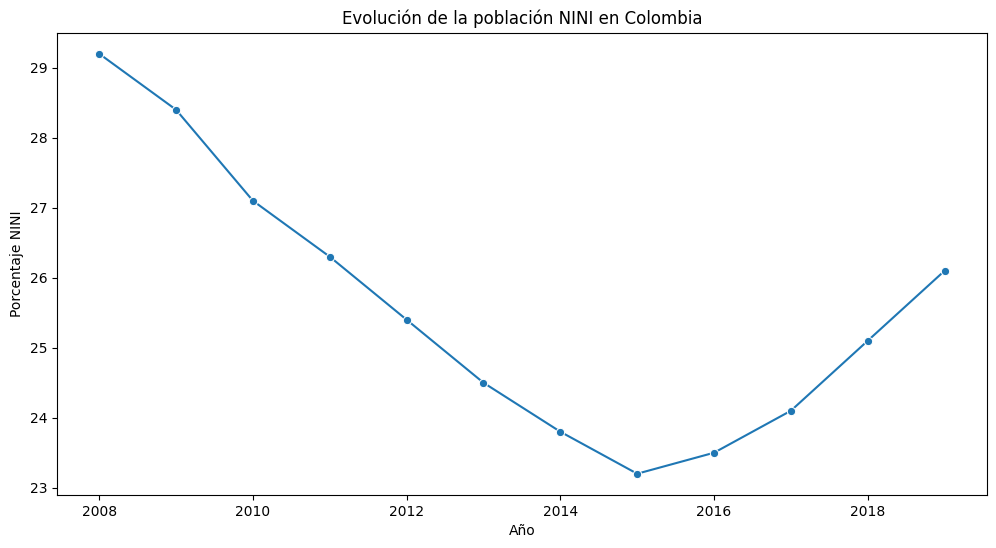

In [21]:
df_nacional = df_NINI[
    df_NINI["Desagregación geográfica"] == "Nacional"
].copy()

df_nacional = df_nacional.sort_values("año")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_nacional,
    x="año",
    y="Valor",
    marker="o"
)

plt.title("Evolución de la población NINI en Colombia")
plt.xlabel("Año")
plt.ylabel("Porcentaje NINI")

plt.show()

In [22]:
df_departamental = df_NINI[
    df_NINI["Desagregación geográfica"] == "Departamental"
].copy()

promedio_departamento = (
    df_departamental
    .groupby("Dominio geográfico")["Valor"]
    .mean()
    .sort_values(ascending=False)
)

print(promedio_departamento)

Dominio geográfico
Chocó                 36.425000
Magdalena             35.591667
Caquetá               35.175000
Sucre                 33.516667
Cesar                 32.600000
Córdoba               32.466667
Caldas                31.141667
Cauca                 30.591667
Bolívar               30.325000
Atlántico             30.050000
Meta                  29.158333
Norte de Santander    28.925000
Quindío               28.550000
Nariño                27.491667
Huila                 26.891667
Risaralda             26.091667
Valle del Cauca       26.075000
La Guajira            25.491667
Tolima                25.300000
Boyacá                24.691667
Antioquia             24.175000
Cundinamarca          20.100000
Santander             19.358333
Bogotá                17.141667
Name: Valor, dtype: float64


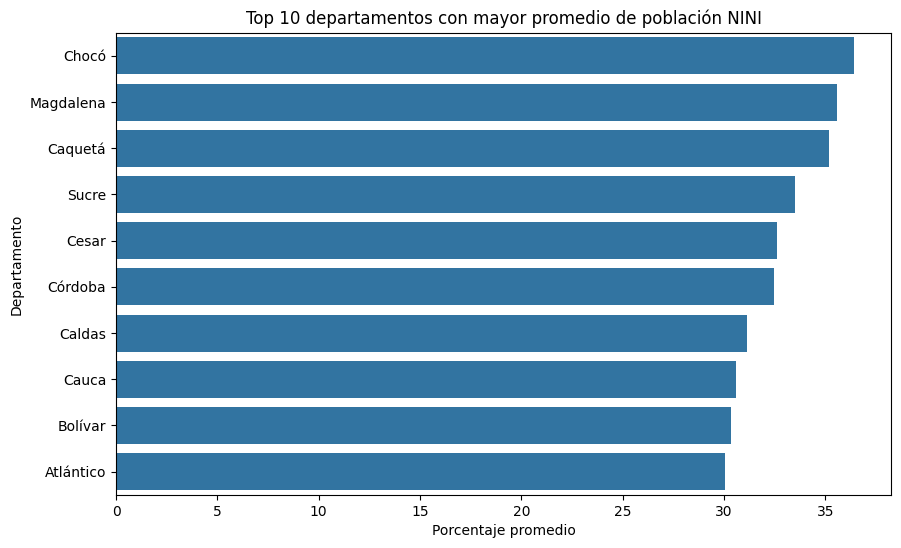

In [23]:
top10 = (
    df_departamental
    .groupby("Dominio geográfico")["Valor"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title(
    "Top 10 departamentos con mayor promedio de población NINI"
)

plt.xlabel("Porcentaje promedio")
plt.ylabel("Departamento")

plt.show()